
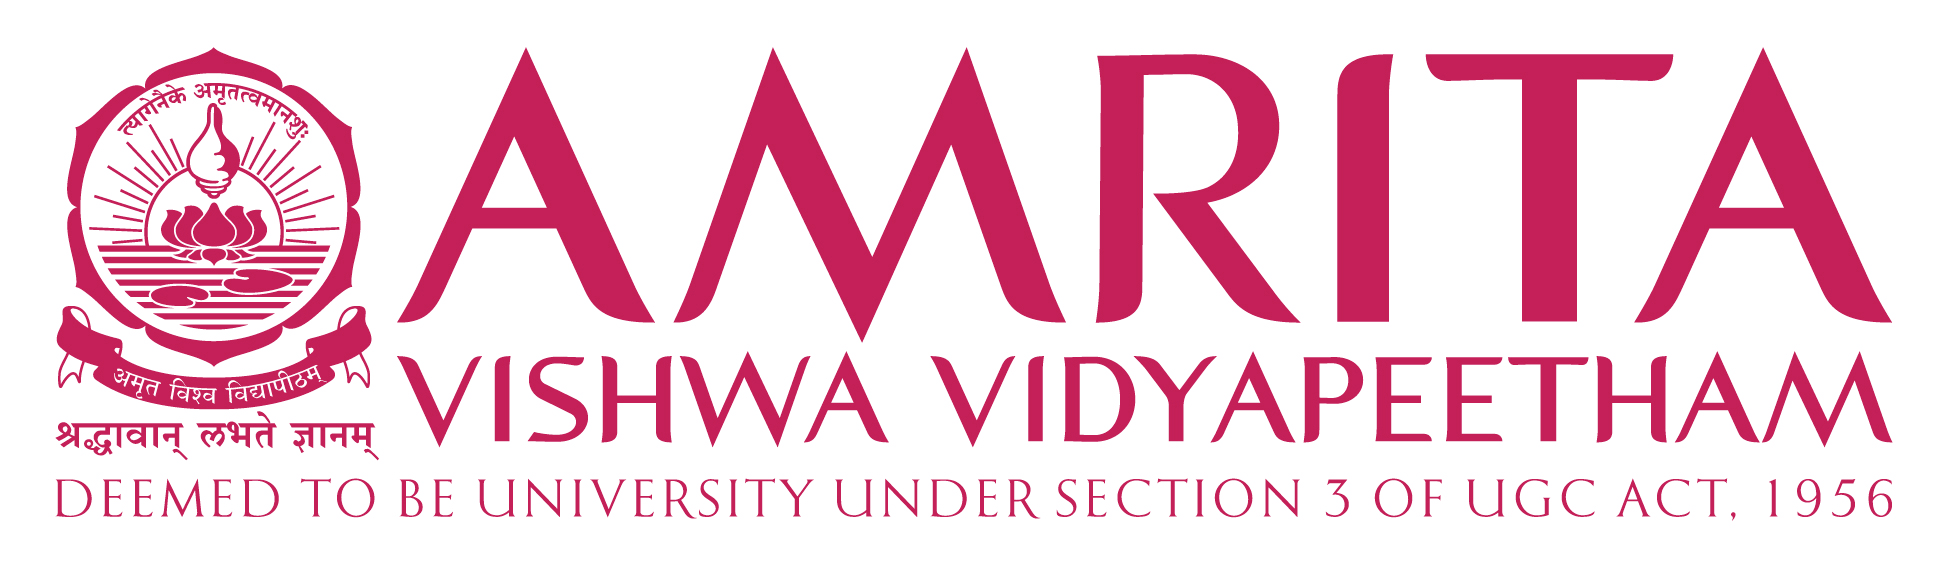
<div >

<h1 align="center" style="font-family: 'Courier New', monospace; font-weight: bold;">
  22MAT220  -   Mathematics for Computing 3
</h1>



<h1 align='center'> Reconstruction and Denoising of the EEG Signals using ADMM</h1>
    
<h3 align='right' >Team members:</h3>
<div align='right'>
  Ravishanmugam K      - CB.SC.U4AIE24347<br>
  Sharvesh Sivagnanam  - CB.SC.U4AIE24355<br>
  Sri Harini M P       - CB.SC.U4AIE24358<br>
  Vignes V M           - CB.SC.U4AIE24359
</div>




</div>
<style>
  .dark-box {
    background-color: #1e1e1e;
    color: #f0f0f0;
    border: 1px solid #444;
    padding: 20px;
    border-radius: 10px;
    font-family: 'Segoe UI', sans-serif;
    text-align:center;
  }
  .dark-box h2 {
    color: #00bfff;
    margin-top: 0;
  }
  .dark-box p {
    color: #ccc;
  }
</style>

<div class="dark-box">
  <h2 style ="text-align:center;">Reconstruction of the EEG Signal </h2>

</div>
Signal reconstruction is like putting a puzzle back together: it's the process of taking sampled data (discrete points) and turning it back into a continuous, original-like signal. After a signal is "sampled" by taking its value at specific points in time, reconstruction recreates the smooth, flowing wave from those isolated data points

<center>
  <img src="eeg-signal1.jpg" alt="Centered Image" width="450"/>
</center>


**EEG-Signal**

Human brain generated weak signals called Electroencephalography (EEG) is measured by the Neurocom EEG 23-channel system ,which is stored in the European Data Format(edf), is used to calcualte the several brain related information ,it can resemble several solutions to the existing problems.It is capable of revealing the emotion and movement controlled by the brain.Around 23 channels contain the information about the signals generated by the brain.Considering an sample of the signals under the compresses sensing concept ,we will reconstruct the signal from the sample(say 25% for this case)

In [162]:
import pyedflib as ed
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct

Reading EEG Signals from EDF files.

In [163]:
edf_path = "Subject00_1.edf"
eegSignal_info = ed.EdfReader(edf_path)

**Dataset Description**

There are totally about 36 subjects(individuals) for the performing the eeg signals , where for each subject is considering the catregory of before and after performing the arithmetic task.Where all the 36 subjects from the 36 were named as subjectxx_1 is signals recored before the performing the airthmetic task and subjectxx_2 is after the arithmetic task.24 subjects were considered to be good quality count(mean number of operation in 4 minutes is 21,SD = 7.4), where remeaning 12 subject are consideres as bad quality count(number of operation in 4 minutes is 7, SD =3.6).Out of 23 channels , only 21 channel's readings were considered for the computation ,as the remaining gave ecg reading.

<center>
  <img src="channel.png" alt="Centered Image" width="450"/>
</center>


In [164]:
print("No.of channels:" , eegSignal_info.signals_in_file)
print("Channel names:",eegSignal_info.getSignalLabels())
print("Dimension of signal in each channel:",eegSignal_info.readSignal(0).size)
print("Dimension of signal:",eegSignal_info.signals_in_file ,",",eegSignal_info.readSignal(1).size)

No.of channels: 21
Channel names: ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']
Dimension of signal in each channel: 91000
Dimension of signal: 21 , 91000


Reading the signal of the channel 1 named as "EEG Fp1".Sampling frequency (also called sampling rate) in EEG signals refers to how often the electrical activity of the brain is recorded per second. It's measured in Hertz (Hz), which means samples per second.

Sample frequency: 500.0


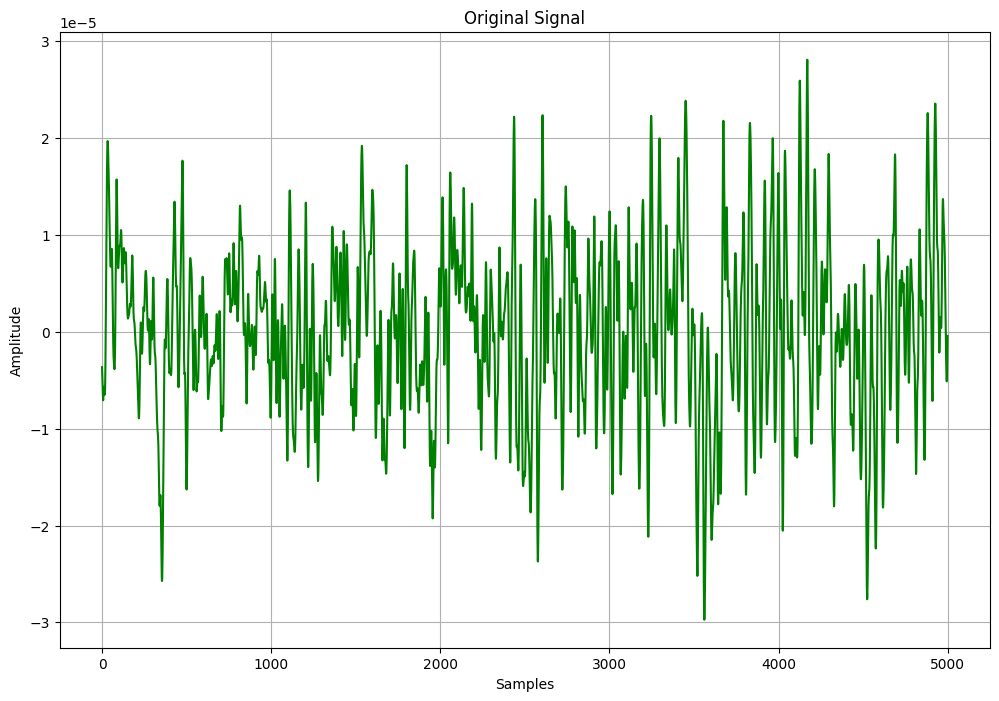

In [165]:
raw_signal = mne.io.read_raw_edf("Subject00_1.edf", preload=True,verbose=False)
signal_1 = raw_signal.get_data()[0,:]
sample_frequency = eegSignal_info.getSampleFrequency(0)
print("Sample frequency:",sample_frequency)

plt.figure(figsize=(12,8))
plt.title("Original Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.plot(signal_1[:5000],color="green")
plt.grid()
plt.show()

**Soft Thresholding**

Soft thresholding is a classical example of the shrinkage function because it reduces the magnitude of values in an controlled way. When applied to a signal, it subtracts a fixed threshold from each value; values below the threshold are set to zero. Unlike hard thresholding, soft thresholding smooths the transition, preserving sparsity while avoiding harsh discontinuities.

<center>
  <img src="soft.jpeg" alt="Centered Image" width="500"/>
</center>

Let $v = s^{k+1} + u^{k}$ and $\tau = \lambda / \rho$.

$$
\mathrm{soft}(v_i, \tau) = \operatorname{sign}(v_i)\, \max(|v_i| - \tau, 0)
$$

Equivalently, in piecewise form for a scalar $v$:

$$
\mathrm{soft}(v,\tau)=\begin{cases}
v-\tau & v>\tau,\\
0 & |v|\le\tau,\\
v+\tau & v< -\tau,
\end{cases}
$$


In [166]:
def soft_threshold(z,lamb):
    return np.sign(z) * np.maximum(np.abs(z) - lamb, 0.0)

In [167]:
high_freq = sample_frequency/2
print("Highest Frequency of the EEG Signal : ",high_freq)

Highest Frequency of the EEG Signal :  250.0


**Compressed Sensing**

Compressed Sensing (CS) is a signal processing technique that allows us to recover a signal from far fewer samples than what traditional Nyquist-Shannon sampling would require, if the signal is sparse in some basis.If the signal has only a few nonzero coefficients in some transform domain (Fourier, Wavelet, DCT, etc.). 
<br>

$f_{\text{sample}} \ge 2 f_{\text{max}}$


Compressed sensing for the Recontruction of the signal is given by, 
$$
y = C x
$$

$ y -$ Compressed Measurement.

$ x -$ Original signal.

$ C -$ random Gaussion Matrix.
Where ,
$$
y \in R^{m},x \in R^{n}, C \in R^{m \times n}.
$$
Here $ n = 5000 $ (original length of the signal),$ m = 0.25 \times n $ (length of the signal after compression) and $ m = 2000 $ (number of coefficients in the basis).

The Z-score normalization $z = \frac{x - \mu}{\sigma}$.
<br>
$\sigma$ - Standard deviation
<br>
$\mu$ - Mean

In [168]:
#compress the data
N:int = 5000
M:int = int(0.25*N)
x = raw_signal.get_data()[0,:N]
original_signal = x
x_mean = np.mean(x)
x_std = np.std(x)
x_norm = (x - x_mean) / x_std #Z score normalization

rng = np.random.default_rng(0)
C = rng.normal(size=(int(M), N)) / np.sqrt(M)
y = C @ x
y_norm = C @ x_norm

**Sparsity in DCT-II Basis**

A "Sparsity Basis" (or sparse basis) is a set of basic components (like vectors or functions) that, when used for a specific task, allow for a sparse representation of data.means the original data can be effectively described using a very small number of these basis elements, with most coefficients being zero.
$$ 
x = \phi s  ,
$$
$$ 
\phi \in R^{n \times n} 
$$

$ \phi $ is DCT coefficient.

$ s $ is sparse vector DCT coefficient
thus the measurement model becomes,
$$ y = Cx = C \phi s = Hs $$
Where $ H = C \phi $ is the effective sensing matrix.
$ H \in R^{m \times n} $ where
$ m <= n $

In [169]:
#dct has many types like DCT-1, DCT-2 and more
phi=np.eye(N)
phi = dct(phi,axis=0, norm='ortho',type=2) #axis=0 create column basis
H = C @ phi

Thus the recovery problem, will be $ s $ (sparsity) from the $y = H s $

LASSO form of the optimisation is 
$$
\min_{s} \left( \frac{1}{2} \| y - Hs \|_2^2 + \lambda \| s \|_1 \right)\
$$
The first term enforces measurement consistency.The second term enforces sparsity.

## Derivation: augmented Lagrangian and ADMM updates

We solve the constrained problem

$$
\min_{s,z}\; \frac{1}{2}\|y-Hs\|_2^2 + \lambda\|z\|_1\quad\text{subject to } s=z.
$$

Lagrangian (with multiplier $\alpha$):

$$
\mathcal{L}(s,z,\alpha)=\tfrac{1}{2}\|y-Hs\|_2^2 + \lambda\|z\|_1 + \alpha^T(s-z).
$$

Augmented Lagrangian penalty $\rho$:

$$
\mathcal{L}_\rho(s,z,\alpha)=\tfrac{1}{2}\|y-Hs\|_2^2 + \lambda\|z\|_1 + \alpha^T(s-z) + \tfrac{\rho}{2}\|s-z\|_2^2.
$$

$$
u = \frac{\alpha}{\rho}
$$

$$
\rho u^T(s-z)+\tfrac{\rho}{2}\|s-z\|_2^2 = \tfrac{\rho}{2}\|s-z+u\|_2^2 - \tfrac{\rho}{2}\|u\|_2^2.
$$


The constant term $\tfrac{\alpha}{\rho}$ does not affect minimization over (s) or (z),
so we use the simplified form used in the notebook:

$$
\tilde{\mathcal{L}}(s,z,u)=\tfrac{1}{2}\|y-Hs\|_2^2 + \lambda\|z\|_1 + \tfrac{\rho}{2}\|s-z+u\|_2^2.
$$

Below are the ADMM block updates obtained by minimizing $(\tilde{\mathcal{L}})$ alternately.

---

### s-update (quadratic minimization)

Solve

$$
s^{k+1}=\arg\min_s \tfrac{1}{2}\|y-Hs\|_2^2 + \tfrac{\rho}{2}\|s-z^k+u^k\|_2^2.
$$

Expand and keep only terms depending on \(s\):

$$
\tilde{\mathcal{L}}(s,z^k,u^k) = \tfrac{1}{2}s^T H^T H s - s^T H^T y + \tfrac{\rho}{2}s^T s - \rho s^T (z^k - u^k) + \text{const}.
$$

Collecting quadratic and linear terms gives

$$
\tilde{\mathcal{L}}(s,z^k,u^k) = \tfrac{1}{2} s^T (H^T H + \rho I) s - s^T (H^T y + \rho (z^k - u^k)) + \text{const}.
$$
<br>

Set gradient to zero: $\tfrac{\partial \mathcal{L}(s,z^k,u^k)}{\partial s} = 0 $

$$
(H^T H + \rho I) s - (H^T y + \rho (z^k - u^k)) = 0
$$



$$
s^{k+1} = (H^T H + \rho I)^{-1}(H^T y + \rho (z^k - u^k)).
$$




---

### z-update (proximal of the l1 norm -> soft threshold)

Solve

$$
z^{k+1}=\arg\min_z \lambda\|z\|_1 + \tfrac{\rho}{2}\|s^{k+1}-z+u^k\|_2^2.
$$

Let $v = s^{k+1} + u^k$, $\tau = \frac{\lambda}{\rho}$.

Shrinkage function with $\lambda \cdot |x|$

$$
\mathrm{soft}(v,\tau)=\operatorname{sign}(v)\max(|v|-\tau,0).
$$



$$
z^{k+1}=\mathrm{soft}(s^{k+1}+u^k,\;\lambda/\rho).
$$
---




### u-update (scaled dual ascent)

The unscaled dual update is

$$
\alpha^{k+1}=\alpha^k + \rho (s^{k+1}-z^{k+1}).
$$

Divide by $\rho$ to get the scaled update

$$
u^{k+1}=u^k + (s^{k+1}-z^{k+1}).
$$


---

### Final ADMM updates (summary)

- $ s^{k+1} = (H^T H + \rho I)^{-1}(H^T y + \rho (z^k - u^k))$
- $z^{k+1} = \mathrm{soft}(s^{k+1} + u^k,\;\lambda/\rho)$
- $u^{k+1} = u^k + (s^{k+1} - z^{k+1})$



In [170]:
#Parameters
max_iteration = 200
rho = 0.5
lam = 0.1

def admm(max_iteration,rho,lam,H,y,N):
    s = y_norm.copy()
    z = np.zeros(N)
    u = np.zeros(N)
    K = np.linalg.inv(H.transpose()@H+ rho * np.eye(N))
    Hy = H.transpose() @ y_norm
    for iteration in range(max_iteration):
        s = K @ (Hy + rho*(z-u))
        z = soft_threshold(s+u,lam/rho)
        u = u + (s-z)
    return s,z,u

sparse_vector,_,_ = admm(max_iteration,rho,lam,H,y,N)
reconstructed_signal_norm = phi @ sparse_vector
reconstructed_signal = reconstructed_signal_norm * x_std + x_mean
print(reconstructed_signal)



[-1.13204198e-06 -4.05827048e-06 -3.73652706e-06 ... -4.83680958e-06
 -3.09278342e-06 -4.18571293e-07]


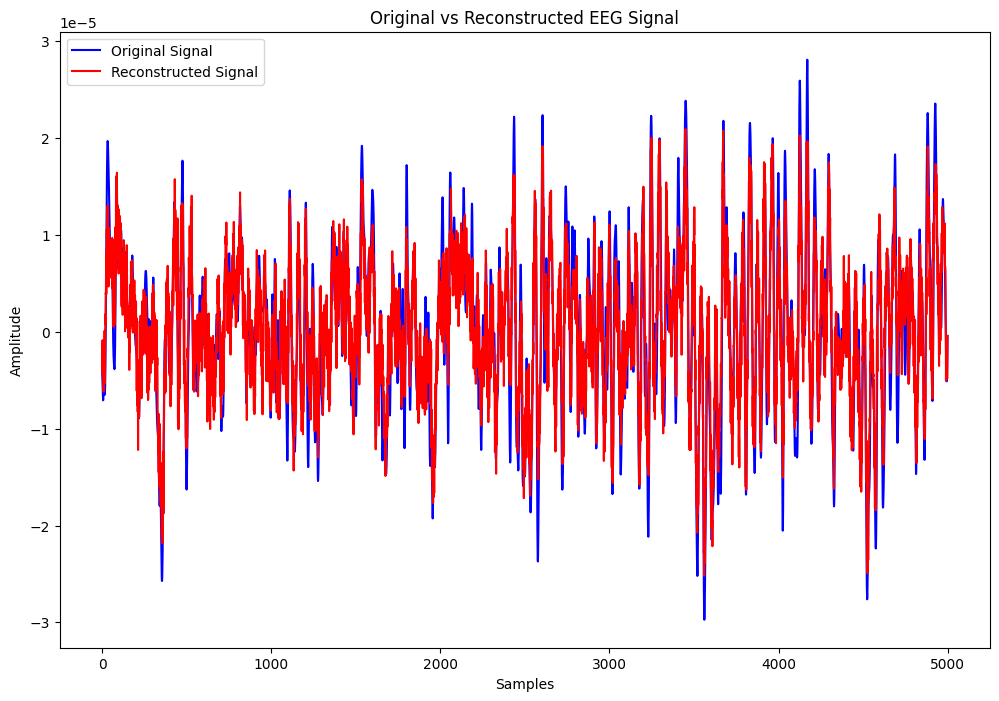

In [171]:
plt.figure(figsize=(12,8))
plt.plot(x, label="Original Signal", color="blue")
plt.plot(reconstructed_signal, label="Reconstructed Signal", color="red")
plt.legend()
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("Original vs Reconstructed EEG Signal")
plt.show()

In [172]:
#rmse
rmse =np.sqrt(np.sum((x-reconstructed_signal)**2)/len(reconstructed_signal))
print("RMSE:",rmse)

RMSE: 4.020593475185363e-06


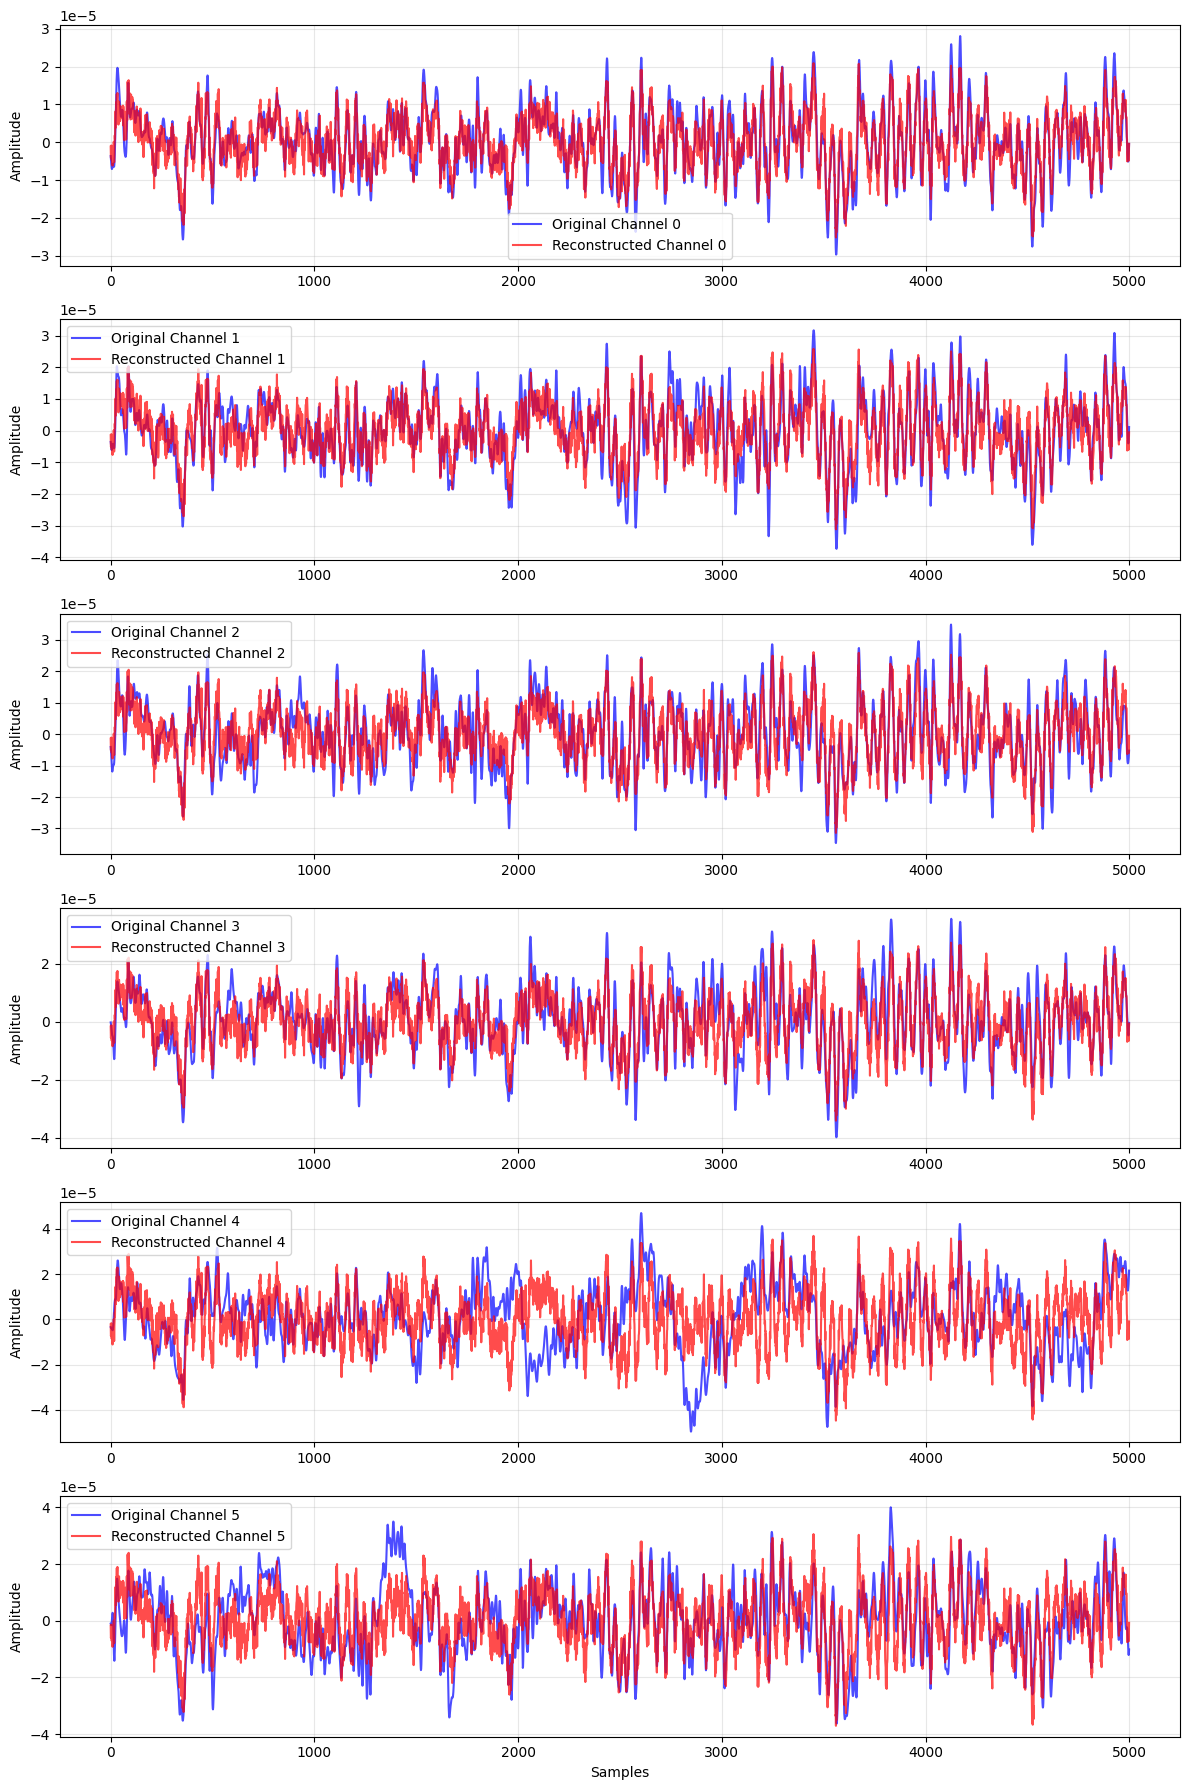

In [173]:
n_channels = 6
channels_to_process = list(range(n_channels))

fig, axes = plt.subplots(n_channels, 1, figsize=(12, 3 * n_channels))

for idx, channel_num in enumerate(channels_to_process):
    x_channel = raw_signal.get_data()[channel_num, :N]
    x_mean_ch = np.mean(x_channel)
    x_std_ch = np.std(x_channel)
    x_norm_ch = (x_channel - x_mean_ch) / x_std_ch

    y_norm_ch = C @ x_norm_ch

    sparse_vector_ch, _, _ = admm(max_iteration, rho, lam, H, y_norm_ch, N)
    reconstructed_signal_norm_ch = phi @ sparse_vector_ch
    reconstructed_signal_ch = reconstructed_signal_norm_ch * x_std_ch + x_mean_ch

    axes[idx].plot(x_channel, label=f"Original Channel {channel_num}", color="blue", alpha=0.7)
    axes[idx].plot(reconstructed_signal_ch, label=f"Reconstructed Channel {channel_num}", color="red", alpha=0.7)
    axes[idx].set_ylabel("Amplitude")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()


<style>
  .dark-box {
    background-color: #1e1e1e;
    color: #f0f0f0;
    border: 1px solid #444;
    padding: 20px;
    border-radius: 10px;
    font-family: 'Segoe UI', sans-serif;
    text-align:center;
  }
  .dark-box h2 {
    color: #00bfff;
    margin-top: 0;
  }
  .dark-box p {
    color: #ccc;
  }
</style>

<div class="dark-box">
  <h2 style ="text-align:center;">Denoising the noisy EEG Signal </h2>

</div>

Signal denoising is the process of removing unwanted or interfering "noise" from a signal to make the true information clearer and more useful

**Gaussian Noise**

In signal processing theory, Gaussian noise, named after Carl Friedrich Gauss, is a kind of signal noise that has a probability density function (pdf) equal to that of the normal distribution (which is also known as the Gaussian distribution).It acts as small in magnitude and high in density aroud the signal.

$$
P(x) = \frac{1}{\sqrt{2\pi\sigma^{2}}} \, e^{-\frac{(x - \mu)^{2}}{2\sigma^{2}}}
$$

$ \mu - $ mean. 

$ \sigma^{2} -$ Standard deviation.

**Laplacian Noise**

Laplace noise is a type of noise that follows a Laplace distribution, also known as a double exponential distribution. It is characterized by two parameters: the location parameter (μ) and the scale parameter (b).In other words , it is high magnitude and less in density.

$$
P(x) = \frac{1}{2b} e^{-\frac{\left| x - \mu \right|}{b}}
$$

$ \mu -$  mean

$ b -$ Scale Parameter

In [174]:
#Adding gaussian noise
def add_gaussian_noise(k, sigma=8e-6,alpha=0.5):
    g = np.random.normal(0, sigma, len(k))

    #for visulisation of the Noise added 
    plt.figure(figsize=(12,8))
    plt.plot(x, label="Original Signal", color="blue")
    plt.plot(g, linestyle='dotted', label="Gaussion Noise", color="Red")
    plt.legend()
    plt.xlim(0,100)
    plt.title("Noise effects on  EEG Signal")
    
    
    plt.show()
    return k + alpha * g

In [175]:
#Adding laplacian noise
def add_laplacian_noise(k,b=8e-6,beta=0.5):
    l = np.random.laplace(0, b, len(k))

    #for visulisation of the Noise added
    plt.figure(figsize=(12,8))
    plt.plot(x, label="Original Signal", color="blue")
    plt.plot(l, linestyle='dotted', label="Laplacian Noise", color="green")
    plt.legend()
    plt.xlim(0,100)
    plt.title("Noise effects on  EEG Signal")
    
    
    plt.show()
    return k + beta * l

In [176]:
#Add both gaussian and laplacian noise
def add_gaussian_laplacian_noise(k, sigma=8e-6, b=8e-6,alpha=0.5,beta=0.5):
    g = np.random.normal(0, sigma, len(k))
    l = np.random.laplace(0, b, len(k))
    plt.show()
    return k + alpha * g + beta * l


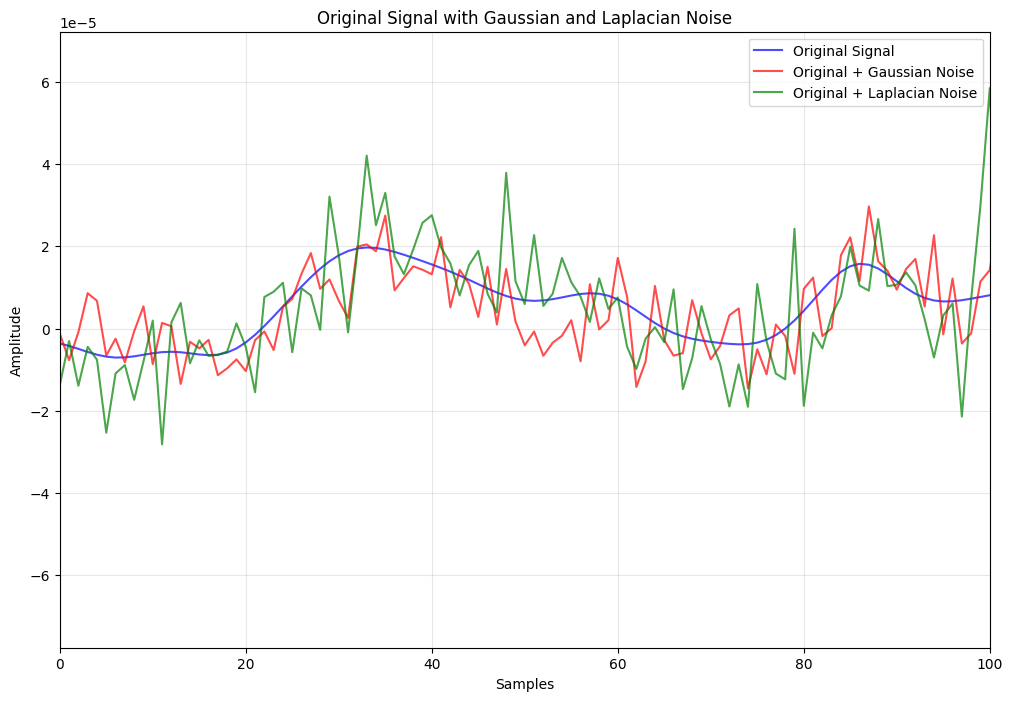

In [183]:
# Plot Gaussian and Laplacian noise
plt.figure(figsize=(12, 8))

# Generate Gaussian noise
gaussian_noise = np.random.normal(0, 8e-6, N)

# Generate Laplacian noise
laplacian_noise = np.random.laplace(0, 8e-6, N)

# Plot both noises
plt.plot(gaussian_noise, label="Gaussian Noise", color="red", alpha=0.7)
plt.plot(laplacian_noise, label="Laplacian Noise", color="green", alpha=0.7)

plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("Gaussian vs Laplacian Noise")
plt.legend()
plt.xlim(0, 1000)
plt.grid(True, alpha=0.3)
plt.show()


error is  7.041808125978782e-06
Size of y: 1250
Size of x: 5000
Size of Noised Signal: 5000


(0.0, 100.0)

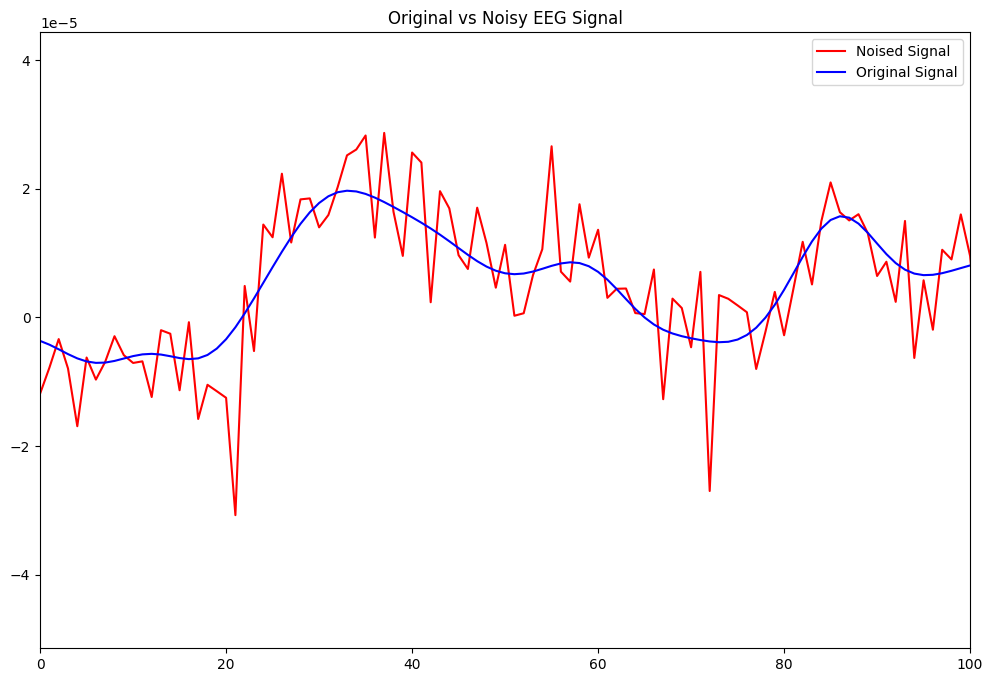

In [178]:
alpha,beta = 1,1
noised_signal = add_gaussian_laplacian_noise(x)
error_signal_Rate = np.sqrt(np.mean((x-noised_signal)**2))
print("error is ",error_signal_Rate)
print("Size of y:",y.size)
print("Size of x:",x.size)
print("Size of Noised Signal:", noised_signal.size)

plt.figure(figsize=(12,8))
plt.plot(noised_signal, label="Noised Signal", color="red")
plt.plot(x, label="Original Signal", color="blue")
plt.title("Original vs Noisy EEG Signal")
plt.legend()
plt.xlim(0,100)

## ADMM Formulation

### Total Variation
In simple terms, Total Variation measures how much a signal "jumps" or changes. A signal with a lot of spikes and oscillations has a high Total Variation, while a smooth or piecewise-constant signal has a low Total Variation.

$$
D = \begin{bmatrix}
-1 & 1 & 0 & \dots & 0 \\
0 & -1 & 1 & \dots & 0 \\
\vdots & \vdots & \ddots & \ddots & \vdots \\
0 & 0 & \dots & -1 & 1
\end{bmatrix}
$$

$$
\mathbf{d} = \mathbf{D}\mathbf{x}
$$

$$
\begin{bmatrix}
d_1 \\
d_2 \\
\vdots \\
d_{n-1}
\end{bmatrix}
=
\begin{bmatrix}
-1 & 1 & 0 & \dots & 0 \\
0 & -1 & 1 & \dots & 0 \\
\vdots & \vdots & \ddots & \ddots & \vdots \\
0 & 0 & \dots & -1 & 1
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}
=
\begin{bmatrix}
x_2 - x_1 \\
x_3 - x_2 \\
\vdots \\
x_n - x_{n-1}
\end{bmatrix}
$$

$$
\mathbf{d}_{(n-1) \times 1} = \mathbf{D}_{(n-1) \times n} \mathbf{x}_{n \times 1}
$$

##### **Smooth signal condition**

$$
\min_{\mathbf{x}} \|\mathbf{d}\|_1 = \min_{\mathbf{x}} \|\mathbf{Dx}\|_1 = \min_{\mathbf{x}} \sum_{i} |x_{i+1} - x_i|
$$

### Objective Equation

$$
\underset{x, n_l, z}{\text{minimize}} \quad \frac{1}{2}\|y - x - n_l\|_2^2 + \gamma \|n_l\|_1 + \lambda \|z\|_1 \quad \text{subject to} \quad z = Dx = d
$$



$$
\begin{align*}
y \quad & \rightarrow \quad \text{The observed, noisy signal (input)} \\
x \quad & \rightarrow \quad \text{The estimated clean, denoised signal (output)} \\
n_l \quad & \rightarrow \quad \text{The estimated Laplacian (spiky) noise component} \\
z \quad & \rightarrow \quad \text{Auxiliary variable representing the signal's gradient } (z \approx Dx)
\end{align*}
$$


$$
L(x, n_l, z, u) = \frac{1}{2}\|y - x - n_l\|_2^2 + \gamma \|n_l\|_1 + \lambda \|z\|_1 + \alpha^T(Dx - z)
$$

$$
L_{\rho}(x, n_l, z, u) = \frac{1}{2}\|y - x - n_l\|_2^2 + \gamma \|n_l\|_1 + \lambda \|z\|_1 + \alpha^T(Dx - z) + \frac{\rho}{2}\|Dx - z\|_2^2
$$
$$
\begin{align*}
\alpha \quad & \rightarrow \quad \text{The dual variable (or Lagrange multiplier)} \\
\rho \quad & \rightarrow \quad \text{The penalty parameter (a constant)}
\end{align*}
$$

### Derivation of the `x`-Update

**1. The `x`-update is defined as the argument that minimizes the Augmented Lagrangian:**
$$
x^{k+1} := \underset{x}{\text{argmin}} \ L_{\rho}(x, n_l^k, z^k, u^k)
$$
$$
u = \alpha/\rho
$$
**2. Isolating the terms from the Lagrangian that depend on `x` gives us the subproblem:**
$$
x^{k+1} = \underset{x}{\text{argmin}} \left( \frac{1}{2}\|y - x - n_l^k\|_2^2 + \frac{\rho}{2}\|Dx - z^k + u^k\|_2^2 \right)
$$

**3. To find the minimum of this convex function, we set its gradient ($\nabla_x$) to zero:**
$$
0 = \nabla_x \left( \frac{1}{2}\|(y - n_l^k) - x\|_2^2 + \frac{\rho}{2}\|Dx - (z^k - u^k)\|_2^2 \right)
$$

**4. Calculating the gradient of each term results in:**
$$
0 = \left( x - (y - n_l^k) \right) + \rho D^T(Dx - (z^k - u^k))
$$

**5. Expanding the terms:**
$$
0 = x - y + n_l^k + \rho D^T Dx - \rho D^T z^k + \rho D^T u^k
$$

**6. Now, we rearrange the equation to solve for `x` by moving all non-`x` terms to the right side:**
$$
x + \rho D^T Dx = y - n_l^k + \rho D^T z^k - \rho D^T u^k
$$

**7. Finally, factoring out `x` on the left and `ρDᵀ` on the right yields the final result:**
$$
(I + \rho D^T D)x = y - n_l^k + \rho D^T(z^k - u^k)
$$

$$
x^{k+1} = (I + \rho D^T D)^{-1} (y - n_l^k + \rho D^T(z^k - u^k))
$$

The $n_l$-update is defined as:
$$
n_l^{k+1} := \underset{n_l}{\text{argmin}} \ L_{\rho}(x^{k+1}, n_l, z^k, u^k)
$$

Isolating the terms dependent on $n_l$ from the Lagrangian:
$$
n_l^{k+1} = \underset{n_l}{\text{argmin}} \left( \frac{1}{2}\|y - x^{k+1} - n_l\|_2^2 + \gamma \|n_l\|_1 \right)
$$

Let the residual signal be $v = y - x^{k+1}$. The problem becomes:
$$
n_l^{k+1} = \underset{n_l}{\text{argmin}} \left( \frac{1}{2}\|v - n_l\|_2^2 + \gamma \|n_l\|_1 \right)
$$


$$
\mathrm{soft}(v,\tau)=\operatorname{sign}(v)\max(|v|-\gamma,0)
$$

$$
n_l^{k+1} = \mathrm{soft}(y - x^{k+1};\gamma)
$$


## Simplified z-update Derivation

The $z$-update is defined as:
$$
z^{k+1} = \underset{z}{\text{argmin}} \ L_{\rho}(x^{k+1}, n_l^{k+1}, z, u^k)
$$


From the augmented Lagrangian, only terms involving $z$ matter for minimization:
$$
z^{k+1} = \underset{z}{\text{argmin}} \left( \lambda \|z\|_1 + u^{k^T}(Dx^{k+1} - z) + \frac{\rho}{2}\|Dx^{k+1} - z\|_2^2 \right)
$$





Let $v = Dx^{k+1} + u^k$. The problem becomes:
$$
z^{k+1} = \underset{z}{\text{argmin}} \left( \lambda \|z\|_1 + \frac{\rho}{2}\|z - v\|_2^2 \right)
$$


This optimization problem has a closed-form solution using the **soft-thresholding operator**, which is the proximal operator of the $\ell_1$ norm:

$$
z^{k+1} = \mathrm{soft}(v, \lambda/\rho) = \mathrm{soft}(Dx^{k+1} + u^k,\;\lambda/\rho)
$$

The **shrinkage function** (soft-thresholding) is defined element-wise as:

$$
\mathrm{soft}(v_i, \tau) = \operatorname{sign}(v_i) \max(|v_i| - \tau, 0)
$$

where $\tau = \lambda/\rho$ is the threshold parameter.

**Why is it called a shrinkage function?**

- It "shrinks" values toward zero by subtracting the threshold $\tau$
- Values with $|v_i| < \tau$ become exactly zero (promotes sparsity)
- Values with $|v_i| > \tau$ are reduced in magnitude by $\tau$
- The sign is preserved, so the function operates symmetrically around zero

This shrinkage property makes soft-thresholding ideal for enforcing sparsity through the $\ell_1$ penalty term $\lambda \|z\|_1$.


### u-update (scaled dual ascent)

The dual variable update step in ADMM keeps track of the constraint violation between $Dx$ and $z$. 

The unscaled dual update is:
$$
\alpha^{k+1} = \alpha^k + \rho (Dx^{k+1} - z^{k+1})
$$

Since we use the scaled form with $u = \frac{\alpha}{\rho}$, dividing both sides by $\rho$ gives the scaled update:

$$
u^{k+1} = u^k + (Dx^{k+1} - z^{k+1})
$$

This update accumulates the residual (difference between $Dx$ and $z$) over iterations, which helps enforce the equality constraint $z = Dx$ in the augmented Lagrangian formulation.

Update equations (Summary):
$$
x^{k+1} = (I + \rho D^T D)^{-1} (y - n_l^k + \rho D^T(z^k - u^k))
$$


$$
n_l^{k+1} = \mathrm{soft}(y - x^{k+1};\gamma)
$$

$$
z^{k+1} = \mathrm{soft}(v, \lambda/\rho) = \mathrm{soft}(Dx^{k+1} + u^k,\,\lambda/\rho)
$$

$$
u^{k+1} = u^k + (Dx^{k+1} - z^{k+1})
$$

Converged after 350 iterations.


Text(0.5, 1.0, 'Denoised signal vs Original Signal')

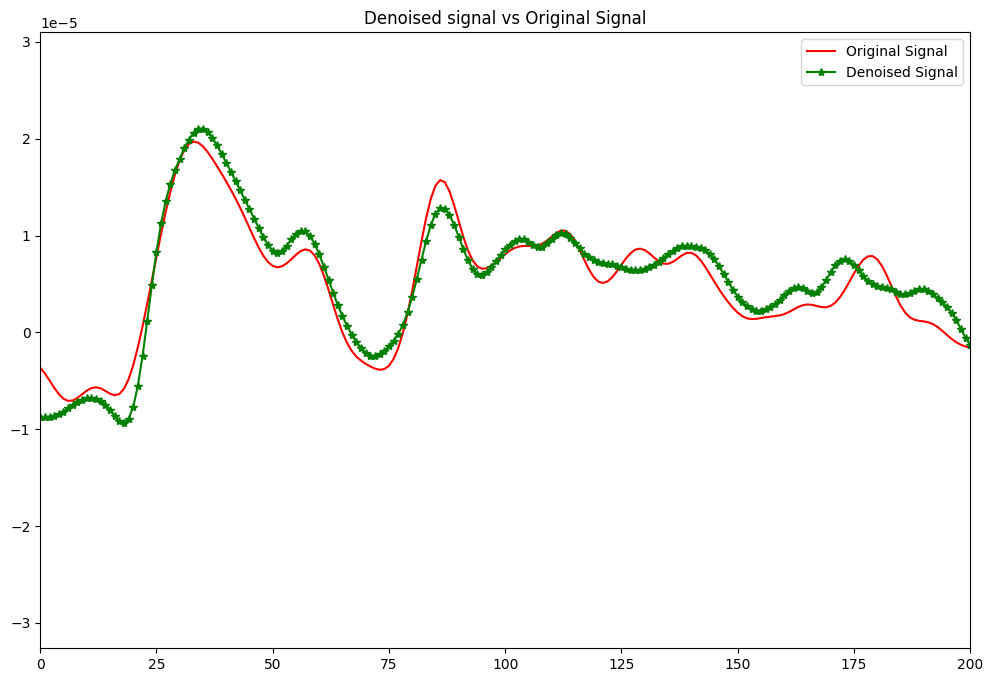

In [179]:
def denoise_mixed_admm_matrix_form(y, lam, gamma, rho=0.014, max_iter=350, tol=1e-6):

    n = len(y)

    # --- 1. Setup operators and precomputations ---
    D = np.eye(n) - np.eye(n, k=1)
    D = D[:-1, :]
    DT = D.T


    I = np.eye(n)
    M = I + rho * DT @ D
    M_inv = np.linalg.inv(M)


    x = y.copy()
    n_l = np.zeros_like(y)
    z = np.zeros(n - 1)
    u = np.zeros(n - 1)

    # --- 3. Run the ADMM Iteration Loop ---
    for k in range(max_iter):
        x_old = x.copy()

        rhs_x = y - n_l + rho * DT @ (z - u)

        x = M_inv @ rhs_x

        n_l = soft_threshold(y - x, gamma)

        # 3. z-update (Gradient update for TV)
        Dx = D @ x
        z = soft_threshold(Dx + u, lam / rho)

        # 4. u-update (Dual variable update)
        u = u + (Dx - z)

        # --- Convergence Check ---
        rel_change = np.linalg.norm(x - x_old) / (np.linalg.norm(x_old) + 1e-9)
        if rel_change < tol:
            break

    print(f"Converged after {k+1} iterations.")
    return x



plt.figure(figsize=(12,8))
denoised_signal = denoise_mixed_admm_matrix_form(noised_signal, lam=0.0001, gamma=0.1)
plt.plot(original_signal, label="Original Signal", color="red")
plt.plot(denoised_signal, label="Denoised Signal", color="green",marker='*', linestyle='-')
plt.legend()
plt.xlim(0,200)
plt.title("Denoised signal vs Original Signal")


In [180]:
rmse_denoising =np.sqrt(np.sum((x-denoised_signal)**2)/len(denoised_signal))
print("RMSE for the DENOISED SIGNAL:",rmse_denoising)

RMSE for the DENOISED SIGNAL: 2.3816269993474694e-06


In [181]:
eegSignal_info.close()
